# **UNIVERSIDAD POLITÉCNICA SALESIANA**

<img src="https://upload.wikimedia.org/wikipedia/commons/b/b0/Logo_Universidad_Polit%C3%A9cnica_Salesiana_del_Ecuador.png" alt="logo universidad" width="550" height="150">

### **CIENCIAS DE LA COMPUTACIÓN - VISIÓN POR COMPUTADOR**

### **PRÁCTICA 0**
---

**Integrantes:** Paúl Sebastián Naspud, Jennyfer Camila Ramírez

24 de Abril de 2026

[Repositorio de GitHub](https://github.com/PaulSebastian9720/Computer_Vision_Portfolio.git)


---

![Rubrica](image.png)



In [ ]:
"""
    Se necesita training_set o images_pr0.zip en la ruta /Practica 0
    /Practica 0/training_set
    /Practica 0/images_pr0.zip
"""

import os
import numpy as np
import matplotlib.pyplot as pltq
from skimage import io, color
from skimage.measure import shannon_entropy
from skimage.util import random_noise
import warnings
warnings.filterwarnings('ignore')

DATASET_PATH = 'training_set'
categories = sorted(os.listdir(DATASET_PATH))
print('Categorías:', categories)

Categorías: ['beaches', 'bus', 'dinosaurs', 'elephants', 'flowers', 'foods', 'horses', 'monuments', 'mountains_and_snow', 'peolpe_and_villages_in_Africa']


## Parte 1 – Imágenes, rutas e histogramas
Una imagen por categoría con su ruta y sus histogramas en escala de grises y a color.

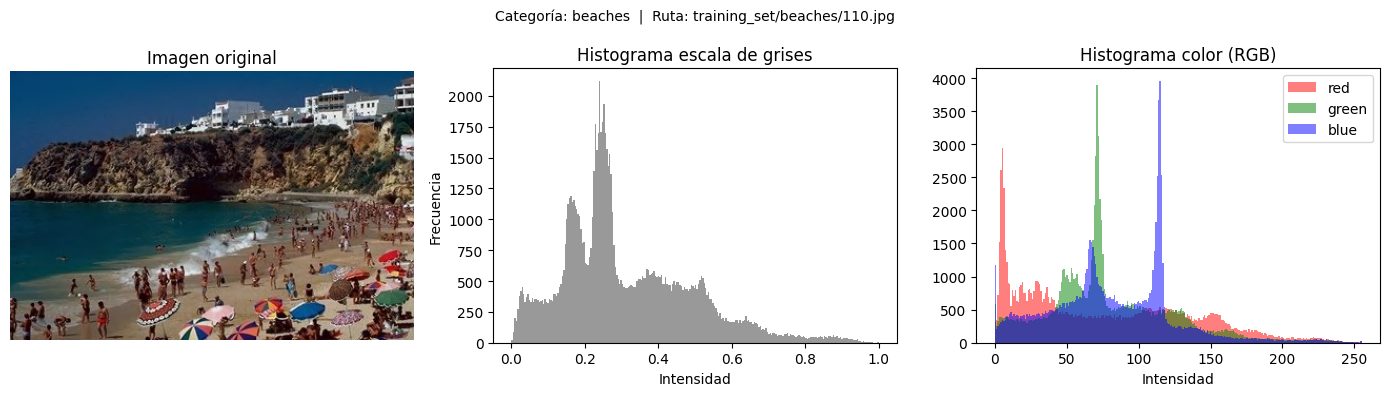

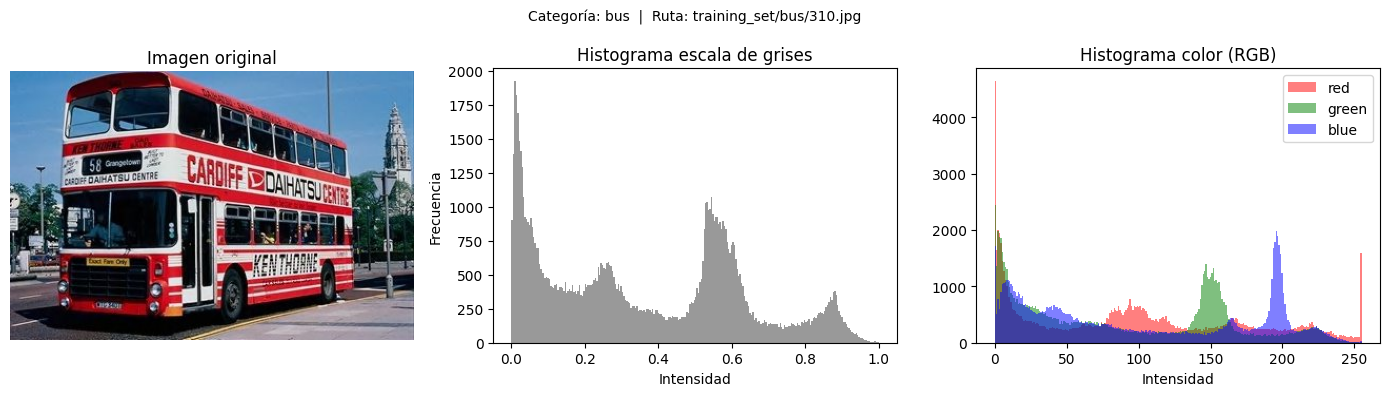

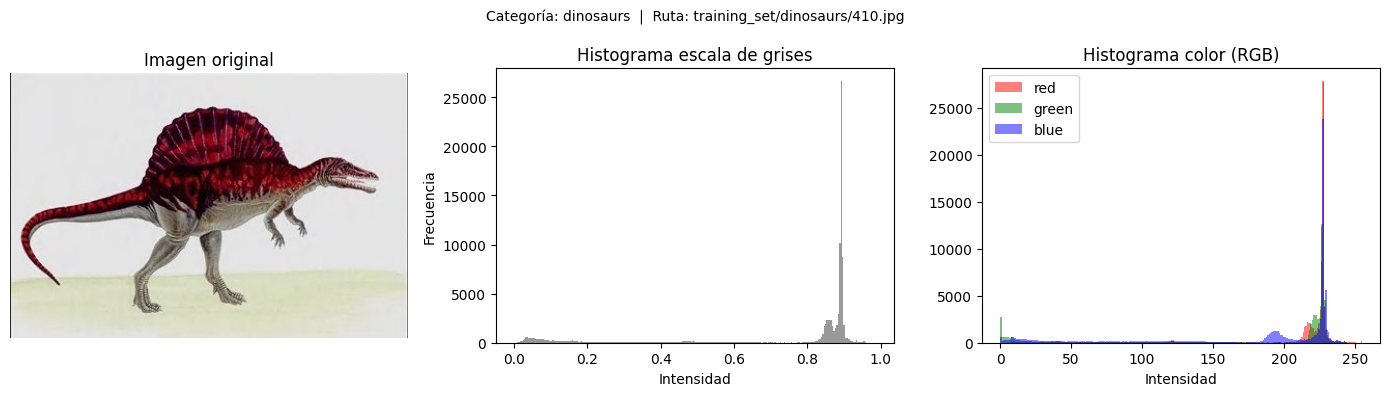

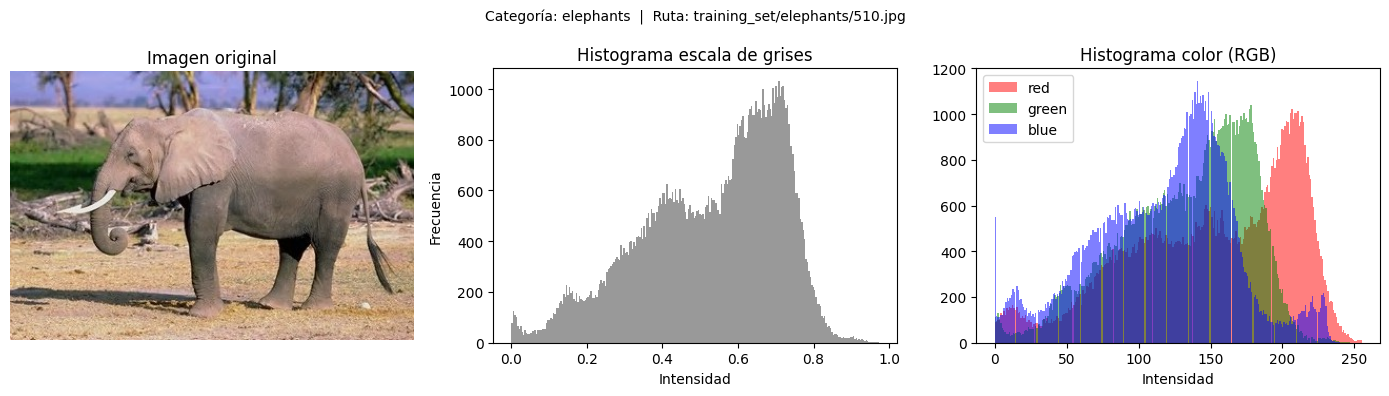

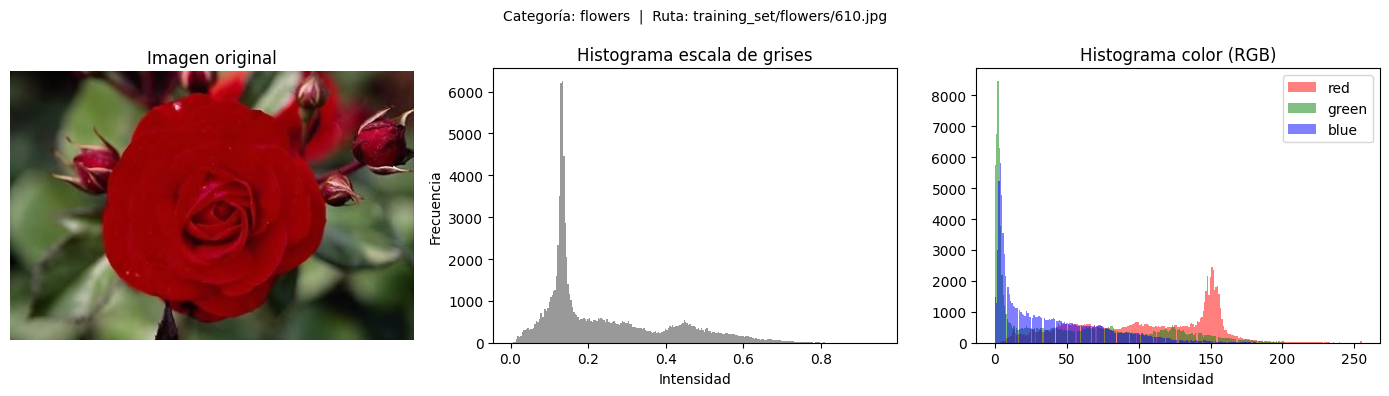

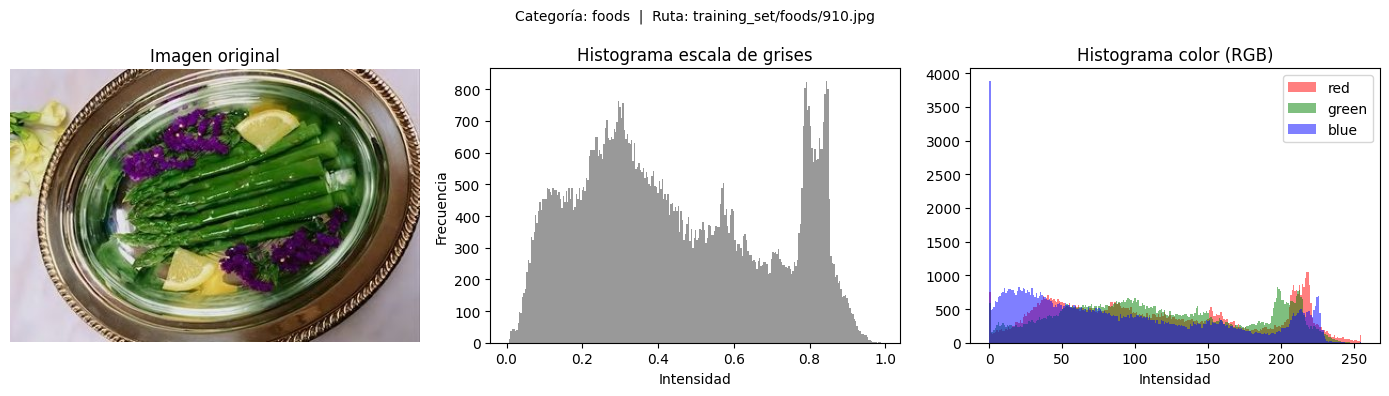

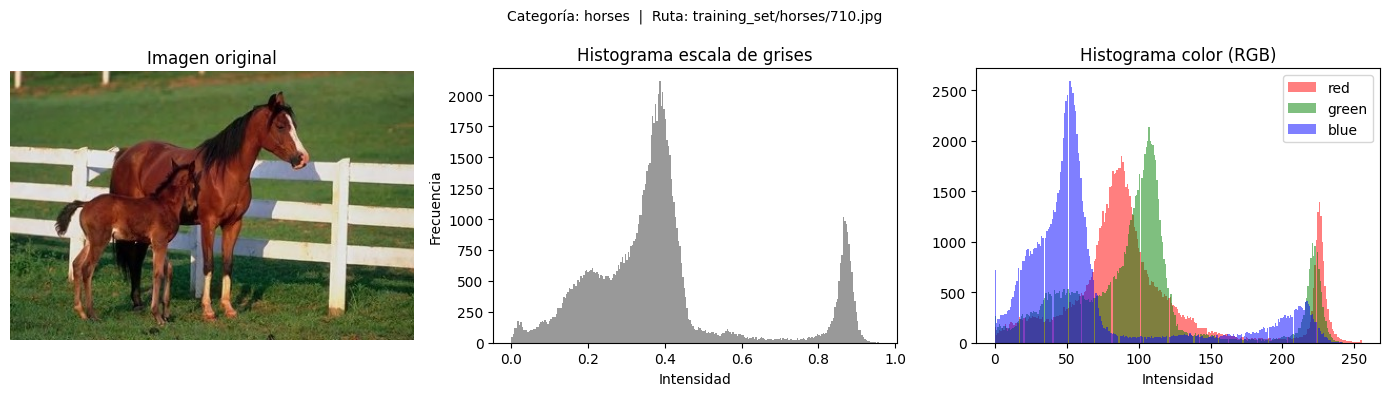

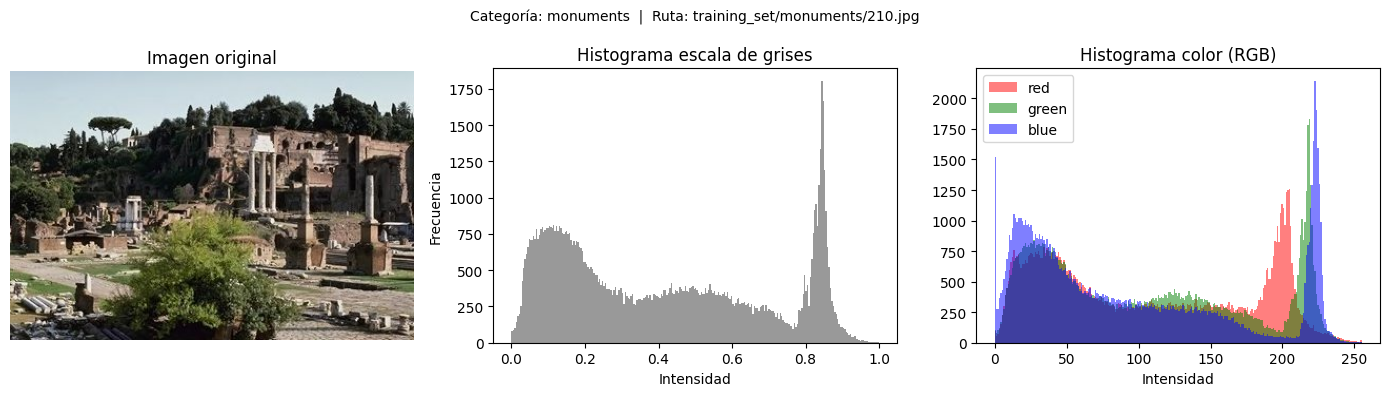

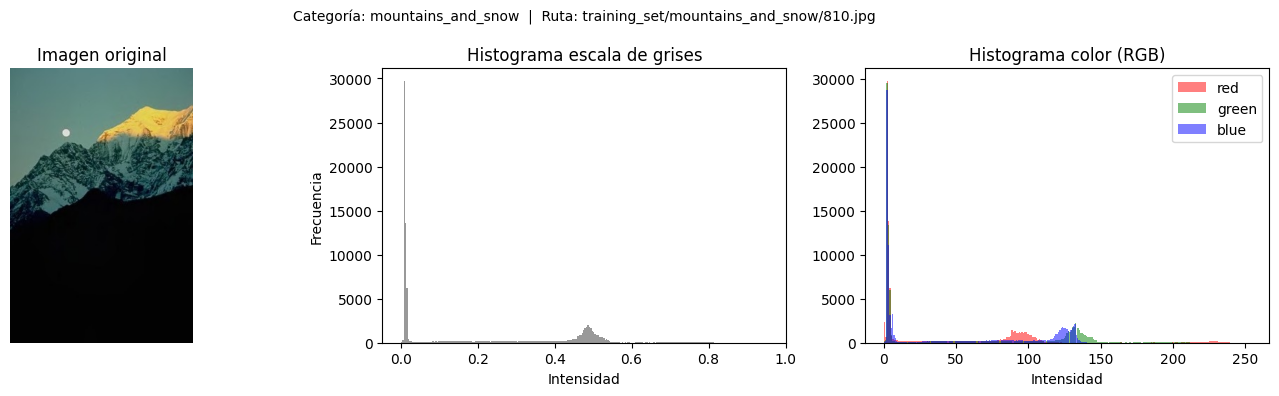

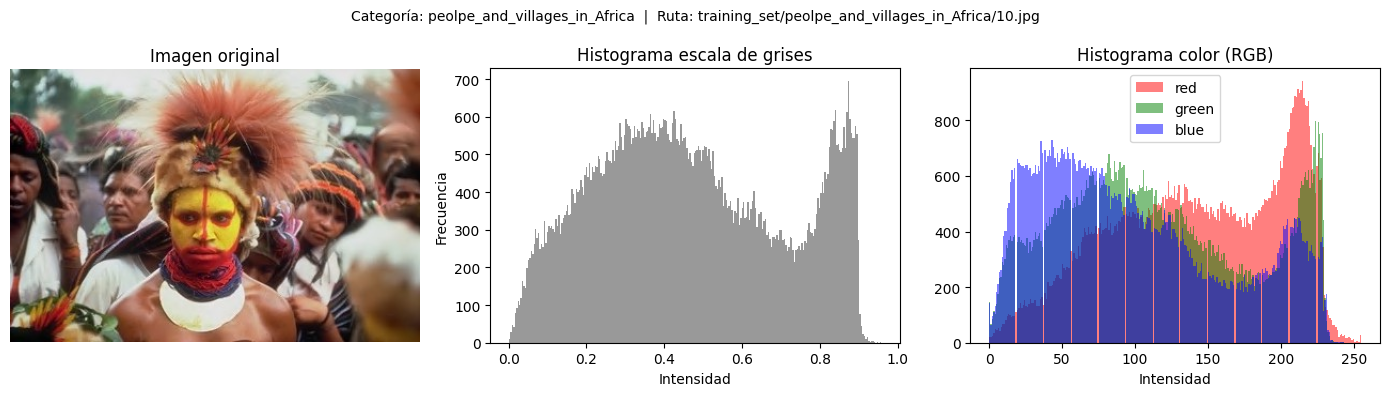

In [2]:
def load_image(img_path):
    img = io.imread(img_path)
    if img.ndim == 2:
        img = np.stack([img]*3, axis=-1)
    if img.shape[2] == 4:
        img = img[:,:,:3]
    return img

def get_first_image(cat_path):
    for f in sorted(os.listdir(cat_path)):
        if f.lower().endswith(('.jpg', '.jpeg', '.png')):
            return os.path.join(cat_path, f)
    return None

for cat in categories:
    img_path = get_first_image(os.path.join(DATASET_PATH, cat))
    if not img_path:
        continue

    img = load_image(img_path)
    img_gray = color.rgb2gray(img)

    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    fig.suptitle(f'Categoría: {cat}  |  Ruta: {img_path}', fontsize=10)

    axes[0].imshow(img)
    axes[0].set_title('Imagen original')
    axes[0].axis('off')

    axes[1].hist(img_gray.ravel(), bins=256, color='gray', alpha=0.8)
    axes[1].set_title('Histograma escala de grises')
    axes[1].set_xlabel('Intensidad'); axes[1].set_ylabel('Frecuencia')

    for ch, col in zip(range(3), ['red', 'green', 'blue']):
        axes[2].hist(img[:,:,ch].ravel(), bins=256, color=col, alpha=0.5, label=col)
    axes[2].set_title('Histograma color (RGB)')
    axes[2].set_xlabel('Intensidad'); axes[2].legend()

    plt.tight_layout()
    plt.show()

## Parte 2 – Entropía de las imágenes

### ¿Qué es la entropía?
La **entropía** mide la cantidad de información o aleatoriedad en una señal. A mayor entropía, mayor variedad de valores y más información contiene la imagen.

- **En escala de grises**: se calcula sobre la distribución de intensidades (0–255). Imágenes con fondos uniformes tienen entropía baja; imágenes con muchas texturas y detalles tienen entropía alta.
- **En color**: se calcula por canal (R, G, B) y se promedia. Valores altos indican gran variedad de tonalidades y saturaciones.

In [3]:
def entropy_gray(img):
    return shannon_entropy(color.rgb2gray(img))

def entropy_color(img):
    return np.mean([shannon_entropy(img[:,:,ch]) for ch in range(3)])

results = {cat: {'gray': [], 'color': []} for cat in categories}

for cat in categories:
    cat_path = os.path.join(DATASET_PATH, cat)
    for fname in sorted(os.listdir(cat_path)):
        if not fname.lower().endswith(('.jpg', '.jpeg', '.png')):
            continue
        try:
            img = load_image(os.path.join(cat_path, fname))
            results[cat]['gray'].append(entropy_gray(img))
            results[cat]['color'].append(entropy_color(img))
        except Exception:
            pass
    print(f'{cat}: {len(results[cat]["gray"])} imágenes')

beaches: 90 imágenes
bus: 90 imágenes
dinosaurs: 90 imágenes
elephants: 90 imágenes
flowers: 90 imágenes
foods: 90 imágenes
horses: 90 imágenes
monuments: 90 imágenes
mountains_and_snow: 90 imágenes
peolpe_and_villages_in_Africa: 90 imágenes


## Parte 3 – Diagrama de cajas y bigotes por categoría

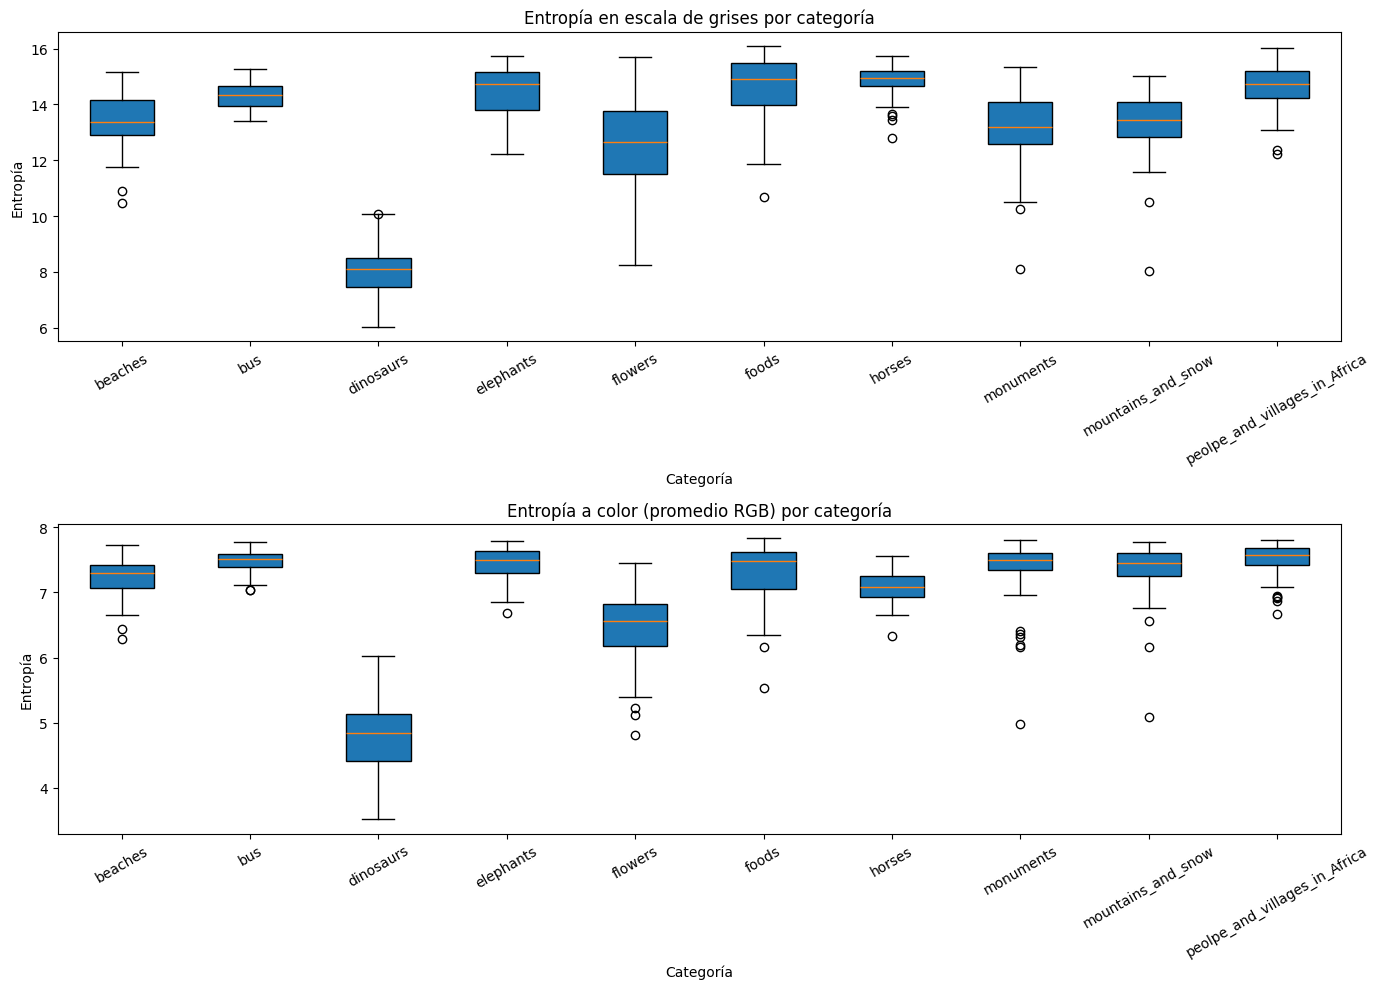

In [4]:
labels     = list(results.keys())
data_gray  = [results[cat]['gray']  for cat in labels]
data_color = [results[cat]['color'] for cat in labels]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

ax1.boxplot(data_gray, labels=labels, patch_artist=True)
ax1.set_title('Entropía en escala de grises por categoría')
ax1.set_xlabel('Categoría'); ax1.set_ylabel('Entropía')
ax1.tick_params(axis='x', rotation=30)

ax2.boxplot(data_color, labels=labels, patch_artist=True)
ax2.set_title('Entropía a color (promedio RGB) por categoría')
ax2.set_xlabel('Categoría'); ax2.set_ylabel('Entropía')
ax2.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

## Parte 4 – Análisis: ¿qué categorías tienen mayor entropía y por qué?

In [5]:
means_gray  = {cat: np.mean(results[cat]['gray'])  for cat in categories}
means_color = {cat: np.mean(results[cat]['color']) for cat in categories}

sorted_gray  = sorted(means_gray.items(),  key=lambda x: x[1], reverse=True)
sorted_color = sorted(means_color.items(), key=lambda x: x[1], reverse=True)

print('=== Entropía promedio (escala de grises) ===')
for cat, val in sorted_gray:
    print(f'  {cat:45s}: {val:.4f}')

print('\n=== Entropía promedio (color) ===')
for cat, val in sorted_color:
    print(f'  {cat:45s}: {val:.4f}')

=== Entropía promedio (escala de grises) ===
  horses                                       : 14.9068
  peolpe_and_villages_in_Africa                : 14.6714
  foods                                        : 14.5451
  elephants                                    : 14.4556
  bus                                          : 14.3285
  beaches                                      : 13.3872
  mountains_and_snow                           : 13.3361
  monuments                                    : 13.2090
  flowers                                      : 12.5544
  dinosaurs                                    : 8.0162

=== Entropía promedio (color) ===
  peolpe_and_villages_in_Africa                : 7.5182
  bus                                          : 7.4825
  elephants                                    : 7.4522
  monuments                                    : 7.3911
  mountains_and_snow                           : 7.3709
  foods                                        : 7.3144
  beaches      

### Explicación
Las categorías con mayor entropía son aquellas con escenas complejas:
- **Playas, bosques, monumentos**: muchas texturas (agua, vegetación, edificios) generan gran variedad de intensidades → entropía alta.
- **Dinosaurios**: imágenes sintéticas con fondos más uniformes → menor entropía.

A mayor variedad de píxeles, más uniforme es su distribución y mayor es la entropía de Shannon.

## Parte 5 – Modificaciones y cambio de entropía
3 niveles de ruido gaussiano sobre 10 imágenes (1 por categoría): pequeño (var=0.005), mediano (var=0.02) y grande (var=0.08).

In [ ]:
"""Código generado con asistencia de Gemini Pro"""

mods = {'pequeña': 0.005, 'mediana': 0.02, 'grande': 0.08}

def apply_noise(img, var):
    noisy = random_noise(img / 255.0, mode='gaussian', var=var)
    return (np.clip(noisy, 0, 1) * 255).astype(np.uint8)

selected = [(cat, get_first_image(os.path.join(DATASET_PATH, cat))) for cat in categories]

mod_results = []

for cat, img_path in selected:
    img = load_image(img_path)
    row = {'cat': cat, 'original': entropy_gray(img)}
    imgs_mod = [img]
    titulos  = [f'Original\nEntropía: {row["original"]:.3f}']

    for nivel, var in mods.items():
        img_mod = apply_noise(img, var)
        row[nivel] = entropy_gray(img_mod)
        imgs_mod.append(img_mod)
        titulos.append(f'{nivel}\nEntropía: {row[nivel]:.3f}')

    mod_results.append(row)

    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    fig.suptitle(f'Categoría: {cat}', fontsize=11)
    for ax, im, title in zip(axes, imgs_mod, titulos):
        ax.imshow(im)
        ax.set_title(title, fontsize=9)
        ax.axis('off')
    plt.tight_layout()
    plt.show()

## Gráfico de barras – comparación de entropía por nivel de modificación

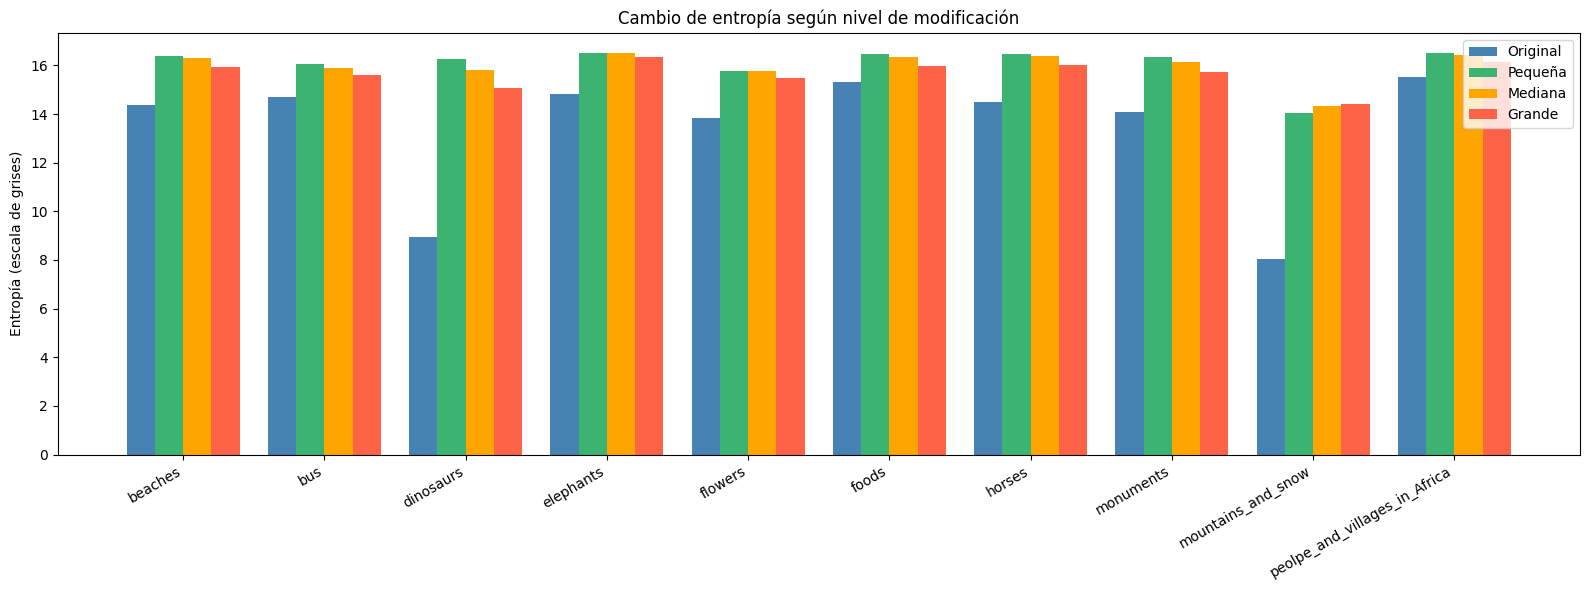

In [7]:
cats_labels = [r['cat'] for r in mod_results]
x     = np.arange(len(cats_labels))
width = 0.2

fig, ax = plt.subplots(figsize=(16, 6))
ax.bar(x - 1.5*width, [r['original'] for r in mod_results], width, label='Original',  color='steelblue')
ax.bar(x - 0.5*width, [r['pequeña']  for r in mod_results], width, label='Pequeña',   color='mediumseagreen')
ax.bar(x + 0.5*width, [r['mediana']  for r in mod_results], width, label='Mediana',   color='orange')
ax.bar(x + 1.5*width, [r['grande']   for r in mod_results], width, label='Grande',    color='tomato')

ax.set_xticks(x)
ax.set_xticklabels(cats_labels, rotation=30, ha='right')
ax.set_ylabel('Entropía (escala de grises)')
ax.set_title('Cambio de entropía según nivel de modificación')
ax.legend()
plt.tight_layout()
plt.show()